In [4]:
!pip install -q torch torchvision kagglehub opencv-python matplotlib

In [7]:
!pip install -q ultralytics
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 7.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [8]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

In [9]:
import kagglehub

path = kagglehub.dataset_download(
    "snehilsanyal/construction-site-safety-image-dataset-roboflow"
)

print("Dataset path:", path)

Using Colab cache for faster access to the 'construction-site-safety-image-dataset-roboflow' dataset.
Dataset path: /kaggle/input/construction-site-safety-image-dataset-roboflow


In [10]:
CLASS_NAMES = [
    "Hardhat",
    "Mask",
    "NO-Hardhat",
    "NO-Mask",
    "NO-Safety Vest",
    "Person",
    "Safety Cone",
    "Safety Vest",
    "machinery",
    "vehicle"
]

print("Number of classes:", len(CLASS_NAMES))

for i, name in enumerate(CLASS_NAMES):
    print(i, "->", name)

Number of classes: 10
0 -> Hardhat
1 -> Mask
2 -> NO-Hardhat
3 -> NO-Mask
4 -> NO-Safety Vest
5 -> Person
6 -> Safety Cone
7 -> Safety Vest
8 -> machinery
9 -> vehicle


Training images: 2605


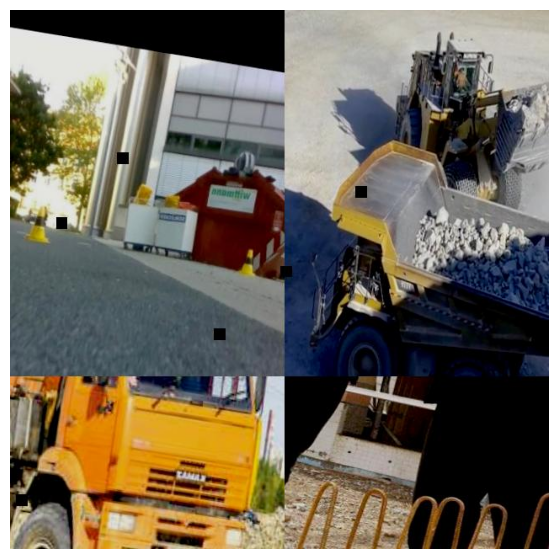

In [11]:
import cv2
import matplotlib.pyplot as plt
import glob
import os

train_images = glob.glob(
    os.path.join(path, "**", "train", "images", "*"),
    recursive=True
)

print("Training images:", len(train_images))

img_path = train_images[0]

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off")
plt.show()

In [12]:
def draw_yolo_labels(image_path):

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    h, w = image.shape[:2]

    label_path = image_path.replace("/images/", "/labels/")
    label_path = os.path.splitext(label_path)[0] + ".txt"

    with open(label_path, "r") as f:
        for line in f:

            values = line.strip().split()

            class_id = int(values[0])

            x_center = float(values[1]) * w
            y_center = float(values[2]) * h
            box_width = float(values[3]) * w
            box_height = float(values[4]) * h

            xmin = int(x_center - box_width / 2)
            ymin = int(y_center - box_height / 2)
            xmax = int(x_center + box_width / 2)
            ymax = int(y_center + box_height / 2)

            cv2.rectangle(
                image,
                (xmin, ymin),
                (xmax, ymax),
                (255, 0, 0),
                2
            )

            cv2.putText(
                image,
                CLASS_NAMES[class_id],
                (xmin, max(ymin - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 0, 0),
                2
            )

    return image

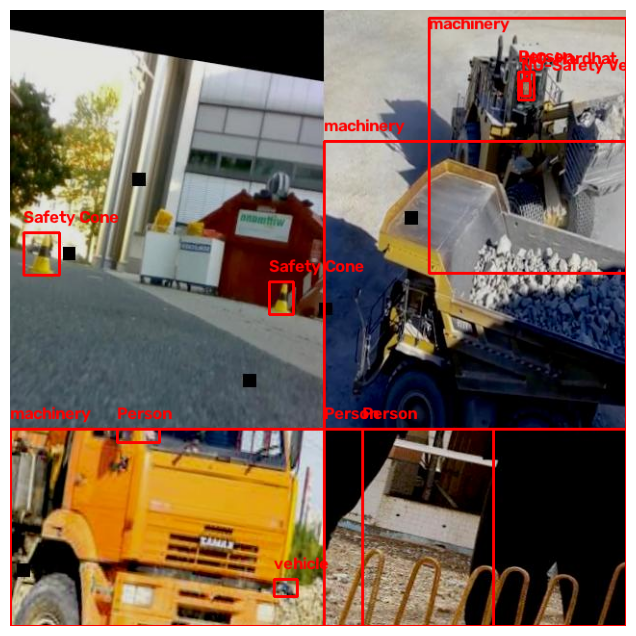

In [13]:
sample = draw_yolo_labels(train_images[0])

plt.figure(figsize=(12,8))
plt.imshow(sample)
plt.axis("off")
plt.show()

In [14]:
import glob

yaml_files = glob.glob(
    os.path.join(path, "**", "*.yaml"),
    recursive=True
)

yaml_files

['/kaggle/input/construction-site-safety-image-dataset-roboflow/results_yolov8n_100e/kaggle/working/ppe_data.yaml',
 '/kaggle/input/construction-site-safety-image-dataset-roboflow/results_yolov8n_100e/kaggle/working/runs/detect/train/args.yaml']

In [16]:
import os

# Define the content of the data.yaml file
yaml_content = f"""
path: {path}/css-data  # Dataset root directory relative to the YAML file or absolute path
train: train/images
val: valid/images
test: test/images # Assuming there is a test set

# Class names
nc: 10 # number of classes
names:
  0: Hardhat
  1: Mask
  2: NO-Hardhat
  3: NO-Mask
  4: NO-Safety Vest
  5: Person
  6: Safety Cone
  7: Safety Vest
  8: machinery
  9: vehicle
"""

# Define the path where the data.yaml will be saved
data_yaml_path = "/content/data.yaml"

# Write the content to the file
with open(data_yaml_path, "w") as f:
    f.write(yaml_content)

print(f"data.yaml created at: {data_yaml_path}")

results = model.train(
    data=data_yaml_path,
    epochs=30,
    imgsz=640,
    batch=8,
    device=0
)

data.yaml created at: /content/data.yaml
Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=None, ops

In [17]:
from ultralytics import YOLO

best_model = YOLO("/content/runs/detect/train-2/weights/best.pt")

In [18]:
import glob
import os

test_images = glob.glob(
    os.path.join(path, "**", "test", "images", "*"),
    recursive=True
)

print("Test images:", len(test_images))
print(test_images[:5])

Test images: 82
['/kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test/images/youtube-198_jpg.rf.e89faeb9765c6bd6cece5434d140f4af.jpg', '/kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test/images/002551_jpg.rf.ce4b9f934161faa72c80dc6898d37b2d.jpg', '/kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test/images/youtube-510_jpg.rf.62f82e36d134d53587edb48f291986f4.jpg', '/kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test/images/004763_jpg.rf.46484e6ca73caeaa9de45822cf1085a9.jpg', '/kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test/images/maksssksksss17_png_jpg.rf.f685b497756b1facbf3d4c2d2d22c0d2.jpg']


In [19]:
results = best_model.predict(
    source=test_images,
    conf=0.5,
    save=True
)


0: 640x640 1 Safety Vest, 3.6ms
1: 640x640 2 Hardhats, 1 NO-Safety Vest, 2 Persons, 3.6ms
2: 640x640 (no detections), 3.6ms
3: 640x640 3 Hardhats, 2 NO-Masks, 3 NO-Safety Vests, 3 Persons, 3.6ms
4: 640x640 1 Mask, 1 NO-Hardhat, 1 Person, 3.6ms
5: 640x640 1 Person, 5 machinerys, 1 vehicle, 3.6ms
6: 640x640 (no detections), 3.6ms
7: 640x640 4 Hardhats, 3 NO-Safety Vests, 6 Persons, 3.6ms
8: 640x640 2 machinerys, 3.6ms
9: 640x640 1 NO-Hardhat, 2 NO-Safety Vests, 2 Persons, 1 machinery, 3.6ms
10: 640x640 1 machinery, 5 vehicles, 3.6ms
11: 640x640 1 Hardhat, 1 NO-Mask, 2 Persons, 1 Safety Vest, 3.6ms
12: 640x640 1 NO-Safety Vest, 1 Person, 3.6ms
13: 640x640 3 Safety Cones, 1 vehicle, 3.6ms
14: 640x640 3 Safety Cones, 1 vehicle, 3.6ms
15: 640x640 1 NO-Safety Vest, 1 Person, 3.6ms
16: 640x640 2 machinerys, 3.6ms
17: 640x640 1 Mask, 1 NO-Safety Vest, 1 Person, 3.6ms
18: 640x640 1 NO-Hardhat, 1 NO-Mask, 1 NO-Safety Vest, 2 Persons, 3.6ms
19: 640x640 1 Mask, 1 NO-Hardhat, 1 NO-Safety Vest, 1 Pe

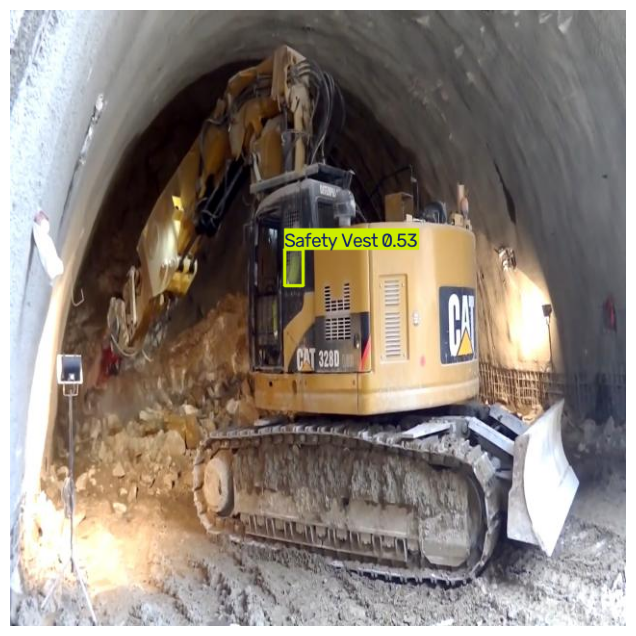

In [20]:
import cv2
import matplotlib.pyplot as plt

result = results[0]

annotated = result.plot()

annotated = cv2.cvtColor(
    annotated,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12,8))
plt.imshow(annotated)
plt.axis("off")
plt.show()

In [21]:
for box in result.boxes:

    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    class_name = best_model.names[class_id]

    print(
        f"Object: {class_name} | "
        f"Confidence: {confidence*100:.2f}%"
    )

Object: Safety Vest | Confidence: 53.13%


In [22]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/runs/detect/train-2/weights/best.pt"
)

In [23]:
import glob
import os

test_images = glob.glob(
    os.path.join(path, "**", "test", "images", "*"),
    recursive=True
)

print("Test images:", len(test_images))

Test images: 82


In [24]:
results = best_model.predict(
    source=test_images[0],
    conf=0.5
)


image 1/1 /kaggle/input/construction-site-safety-image-dataset-roboflow/css-data/test/images/youtube-198_jpg.rf.e89faeb9765c6bd6cece5434d140f4af.jpg: 640x640 1 Safety Vest, 9.6ms
Speed: 1.1ms preprocess, 9.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


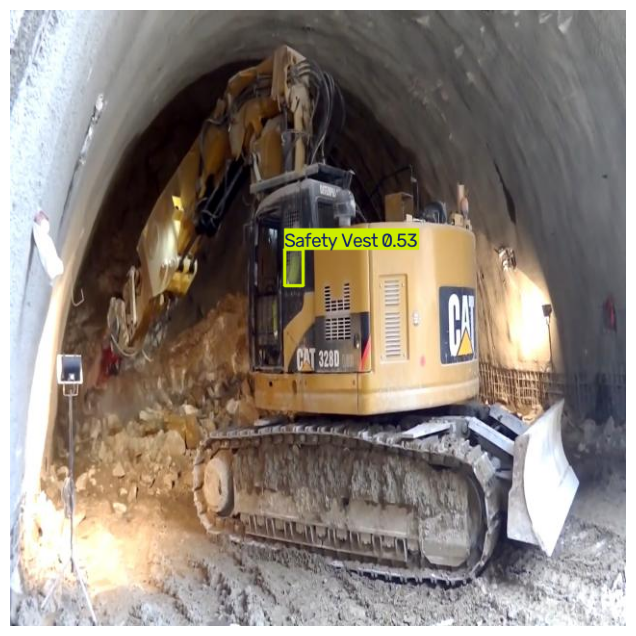

In [25]:
import cv2
import matplotlib.pyplot as plt

result = results[0]

img = result.plot()
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.axis("off")
plt.show()